## **Smart Traffic Clustering System**

### *Unsupervised Machine Learning Analysis of Urban Traffic Data*

---

### **Dataset**

* **File:** `all_features_traffic_dataset.csv`
* **Time Period:** 2018 – 2024
* **Size:** 61,368 rows × 30 features

---

### **Algorithms Used**

* **K-Means Clustering**
* **DBSCAN (Density-Based Spatial Clustering)**
* **Agglomerative Hierarchical Clustering** *(applied on a 5,000-row sample to prevent memory overflow)*
* **PCA (Principal Component Analysis)** — dimensionality reduction & visualization
* **Local Outlier Factor (LOF)** — anomaly detection

---

### **Project Objective**

* Identify **distinct traffic congestion patterns** across road segments and time periods
* Discover **hidden structures** in traffic flow using unsupervised learning
* Detect **anomalous traffic events** such as unusual congestion or disruptions
* Support **intelligent traffic management systems** with data-driven insights


## **Step 1 — Install Required Libraries**

Install all necessary Python packages required for this project.
Run this cell once before executing any other part of the notebook.


In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn plotly scipy --quiet

## **Step 2 — Import Libraries & Configure Settings**

Load all required libraries and configure global settings for the project.
Set a fixed random seed (`42`) to ensure reproducibility, so running the notebook multiple times produces consistent and identical results.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn — clustering, preprocessing, evaluation
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score)
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

# Scipy — hierarchical dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Plotly — interactive 3-D visualisation
import plotly.express as px
import plotly.graph_objects as go

# Global plot settings
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["font.size"]      = 12
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("viridis")
np.random.seed(42)

print("All libraries imported successfully.")
print(f"NumPy {np.__version__}  |  Pandas {pd.__version__}")

All libraries imported successfully.
NumPy 2.0.2  |  Pandas 2.2.2


## **Step 3 — Load & Inspect the Dataset**

Load the CSV file and parse the `Timestamp` column as a datetime object.
Perform an initial data inspection by displaying the dataset shape, date range, missing values, and the distribution of the target label `Congestion_Level`.


In [ ]:
df = pd.read_csv("all_features_traffic_dataset.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("=== Dataset Overview ===")
print(f"Shape            : {df.shape}")
print(f"Date range       : {df['Timestamp'].min()}  to  {df['Timestamp'].max()}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print()

missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols):
    print("Columns with missing values:")
    print(missing_cols)
else:
    print("No missing values in any column (except Incidents_or_Events which is intentionally sparse).")

print()
print("Congestion Level distribution:")
print(df["Congestion_Level"].value_counts())
print()
print("Numerical summary:")
df[["Traffic_Volume","Traffic_Speed","Traffic_Density",
    "Travel_Time","Emission_Levels"]].describe().round(2)

=== Dataset Overview ===
Shape            : (47206, 30)
Date range       : 2018-01-01 00:00:00  to  2023-05-21 21:00:00
Total missing    : 32950

Columns with missing values:
Traffic_Density                  1
Time_of_Day                      1
Day_of_Week                      1
Weather_Conditions               1
Road_Segment_ID                  1
Road_Length                      1
Number_of_Lanes                  1
Intersection_Info                1
Traffic_Signals                  1
Proximity_to_POI                 1
Adjacency_Matrix                 1
Node_Features                    1
Edge_Weights                     1
Previous_Time_Steps              1
Incidents_or_Events          32924
Population_Density               1
Public_Transport_Data            1
Real_Time_GPS_Data               1
Travel_Time                      1
Congestion_Level                 1
Delay_Reduction                  1
Optimal_Routing_Decisions        1
Emission_Levels                  1
Traffic_Incidents   

,Traffic_Volume,Traffic_Speed,Traffic_Density,Travel_Time,Emission_Levels
count,47206.00,47206.00,47205.00,47205.00,47205.00
mean,2528.74,50.03,40.73,9.20,1.05
std,1426.49,15.07,23.24,6.17,0.55
min,50.00,5.00,10.00,0.37,0.10
25%,1299.00,39.84,20.00,5.43,0.57
50%,2534.00,50.15,30.00,8.30,1.04
75%,3754.00,60.23,50.00,11.62,1.52
max,5000.00,111.51,100.00,122.20,2.00


## **Step 4 — Exploratory Data Analysis (EDA)**

Visualize the raw distributions of key traffic features and temporal patterns before applying any modeling techniques.
Six subplots are generated:

1. Traffic Speed distribution with mean indicator
2. Traffic Volume distribution
3. Traffic Density distribution
4. Hourly average density (with peak-hour highlighting)
5. Top 10 road segments by average density
6. Day-of-week average density


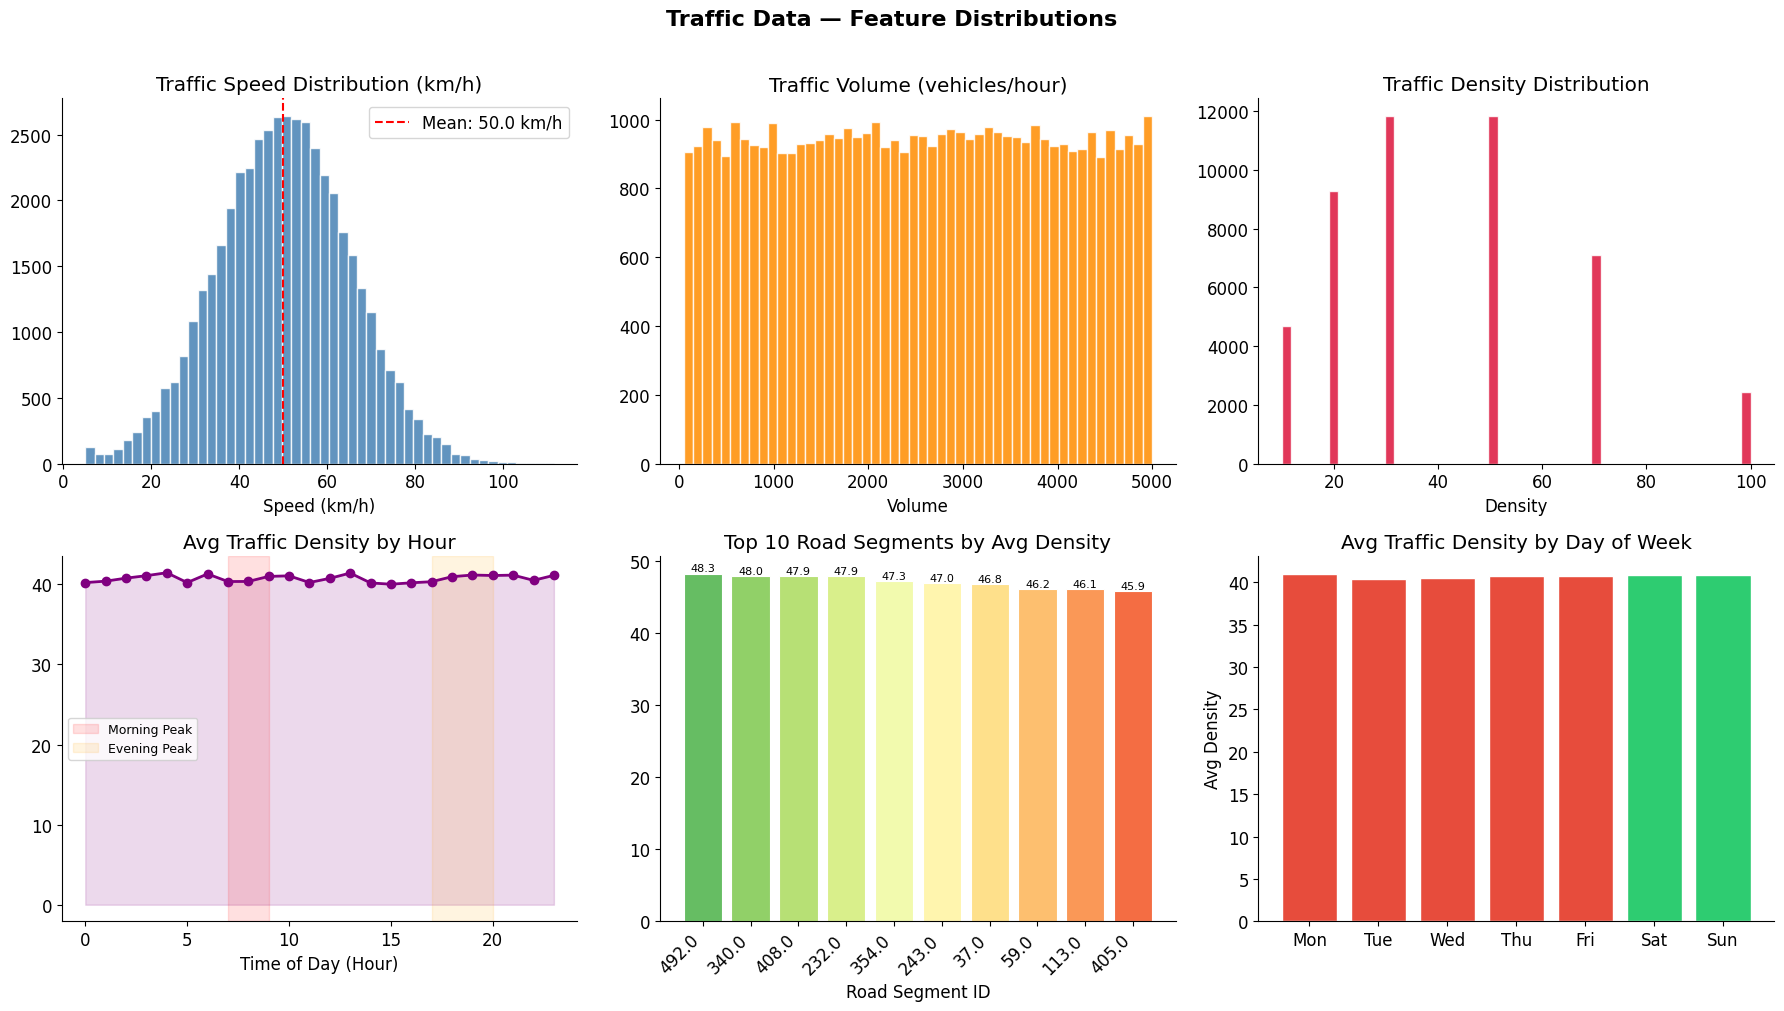

Plot saved: eda_overview.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Traffic Data — Feature Distributions", fontsize=16, fontweight="bold", y=1.01)

# Speed
axes[0,0].hist(df["Traffic_Speed"], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0,0].axvline(df["Traffic_Speed"].mean(), color="red", linestyle="--",
                  label=f"Mean: {df['Traffic_Speed'].mean():.1f} km/h")
axes[0,0].set_title("Traffic Speed Distribution (km/h)")
axes[0,0].set_xlabel("Speed (km/h)")
axes[0,0].legend()

# Volume
axes[0,1].hist(df["Traffic_Volume"], bins=50, color="darkorange", edgecolor="white", alpha=0.85)
axes[0,1].set_title("Traffic Volume (vehicles/hour)")
axes[0,1].set_xlabel("Volume")

# Density
axes[0,2].hist(df["Traffic_Density"], bins=50, color="crimson", edgecolor="white", alpha=0.85)
axes[0,2].set_title("Traffic Density Distribution")
axes[0,2].set_xlabel("Density")

# Hourly pattern
hourly = df.groupby("Time_of_Day")["Traffic_Density"].mean()
axes[1,0].plot(hourly.index, hourly.values, "o-", color="purple", linewidth=2, markersize=6)
axes[1,0].fill_between(hourly.index, hourly.values, alpha=0.15, color="purple")
axes[1,0].axvspan(7,  9,  alpha=0.12, color="red",    label="Morning Peak")
axes[1,0].axvspan(17, 20, alpha=0.12, color="orange", label="Evening Peak")
axes[1,0].set_title("Avg Traffic Density by Hour")
axes[1,0].set_xlabel("Time of Day (Hour)")
axes[1,0].legend(fontsize=9)

# Top-10 road segments
zone_cong = (df.groupby("Road_Segment_ID")["Traffic_Density"]
               .mean().sort_values(ascending=False).head(10))
bars = axes[1,1].bar(zone_cong.index.astype(str), zone_cong.values,
                     color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 10)),
                     edgecolor="white", linewidth=0.8)
axes[1,1].set_title("Top 10 Road Segments by Avg Density")
axes[1,1].set_xlabel("Road Segment ID")
axes[1,1].set_xticklabels(zone_cong.index.astype(str), rotation=45, ha="right")
for bar, val in zip(bars, zone_cong.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.005,
                   f"{val:.1f}", ha="center", va="bottom", fontsize=8)

# Day of week
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily = df.groupby("Day_of_Week")["Traffic_Density"].mean()
daily_ordered = [daily.get(i, 0) for i in range(7)]
colors_day = ["#e74c3c" if d < 5 else "#2ecc71" for d in range(7)]
axes[1,2].bar(days, daily_ordered, color=colors_day, edgecolor="white")
axes[1,2].set_title("Avg Traffic Density by Day of Week")
axes[1,2].set_ylabel("Avg Density")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: eda_overview.png")

## **Step 5 — Correlation Analysis & Peak vs Off-Peak Comparison**

**Left Panel:** A Pearson correlation heatmap of numerical features, highlighting relationships between variables (e.g., higher traffic density correlating with increased travel time).

**Right Panel:** A comparative bar chart showing feature averages during peak hours versus off-peak hours, based on the `Peak_Hour_Prediction` column.


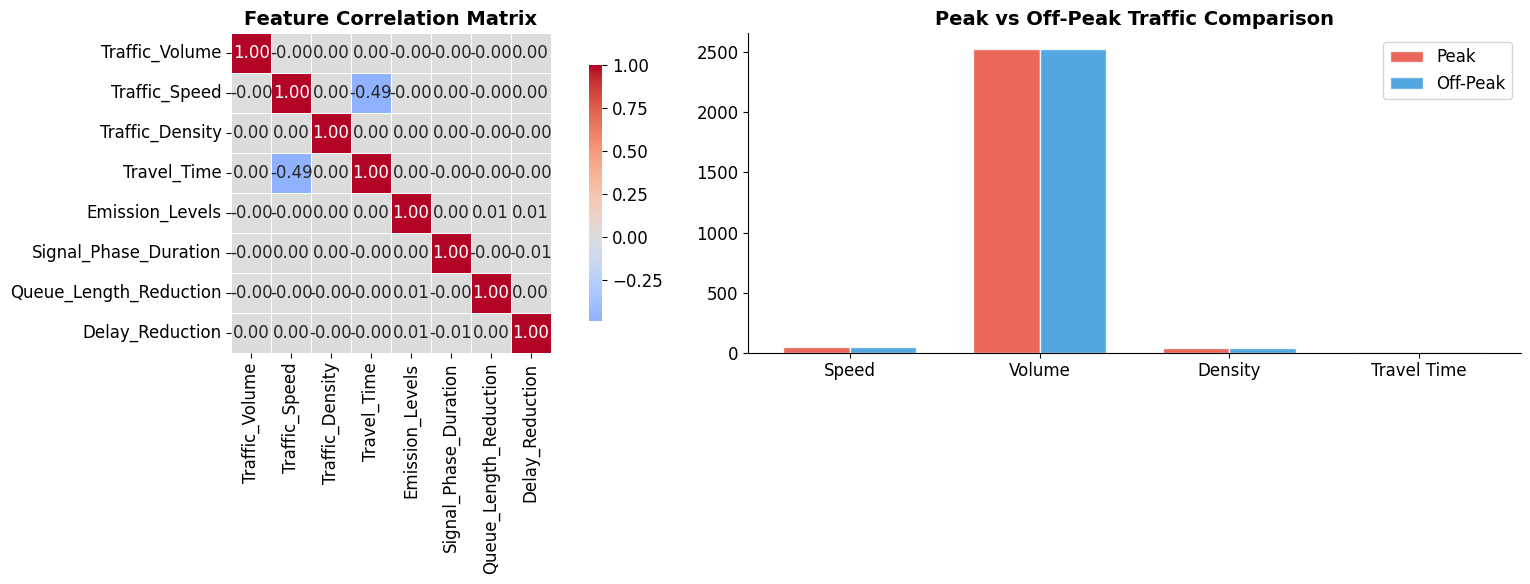

Plot saved: correlation_analysis.png


In [ ]:
# Build is_peak flag from Peak_Hour_Prediction
df["is_peak"] = df["Peak_Hour_Prediction"].apply(
    lambda x: 1 if x in ["Morning Peak", "Evening Peak", "Afternoon Peak"] else 0
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Correlation heatmap
num_cols = ["Traffic_Volume","Traffic_Speed","Traffic_Density",
            "Travel_Time","Emission_Levels","Signal_Phase_Duration",
            "Queue_Length_Reduction","Delay_Reduction"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=axes[0],
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")

# Peak vs off-peak
df_peak    = df[df["is_peak"] == 1]
df_offpeak = df[df["is_peak"] == 0]
features   = ["Traffic_Speed","Traffic_Volume","Traffic_Density","Travel_Time"]
x = np.arange(len(features))
w = 0.35
axes[1].bar(x - w/2, df_peak[features].mean().values,    w, label="Peak",     color="#e74c3c", alpha=0.85, edgecolor="white")
axes[1].bar(x + w/2, df_offpeak[features].mean().values, w, label="Off-Peak", color="#3498db", alpha=0.85, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Speed","Volume","Density","Travel Time"])
axes[1].set_title("Peak vs Off-Peak Traffic Comparison", fontsize=14, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("correlation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: correlation_analysis.png")

## **Step 6 — Feature Engineering**

Raw columns are enhanced by creating meaningful derived features to improve clustering performance.
These include cyclic encoding for time (`hour_sin`, `hour_cos`, `day_sin`, `day_cos`), numerical encoding for incidents and weather, a composite `risk_score`, `flow_efficiency`, and a `month` feature for seasonality.

A total of **13 features** are then selected and standardized using `StandardScaler` to ensure zero mean and unit variance.


In [ ]:
def engineer_features(df):
    df = df.copy()

    # Cyclic time encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["Time_of_Day"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["Time_of_Day"] / 24)
    df["day_sin"]  = np.sin(2 * np.pi * df["Day_of_Week"] / 7)
    df["day_cos"]  = np.cos(2 * np.pi * df["Day_of_Week"] / 7)

    # Incident encoding — matches actual values in dataset
    incident_map = {"No Incident": 0, "Minor": 1, "Major": 2}
    df["incidents_numerical"] = df["Traffic_Incidents"].map(incident_map).fillna(0)

    # Weather encoding
    weather_map = {"Clear": 0, "Fog": 1, "Rain": 2, "Snow": 3, "Extreme": 4}
    df["weather_numerical"] = df["Weather_Conditions"].map(weather_map).fillna(0)

    # Composite risk score
    df["risk_score"] = (
        df["incidents_numerical"] / 2 * 0.4 +
        df["Traffic_Density"] / df["Traffic_Density"].max() * 0.4 +
        df["weather_numerical"] / 4 * 0.2
    )

    # Flow efficiency
    df["flow_efficiency"] = df["Traffic_Speed"] / (df["Traffic_Volume"] + 1)

    # Month from timestamp
    df["month"] = df["Timestamp"].dt.month

    return df

df = engineer_features(df)

CLUSTER_FEATURES = [
    "Traffic_Speed", "Traffic_Volume", "Traffic_Density",
    "risk_score", "flow_efficiency",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "incidents_numerical", "weather_numerical",
    "Travel_Time", "Emission_Levels"
]

df_clean = df.dropna(subset=CLUSTER_FEATURES).copy().reset_index(drop=True)
X = df_clean[CLUSTER_FEATURES].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature engineering complete.")
print(f"Full dataset rows : {len(df):,}")
print(f"Clean rows used   : {len(df_clean):,}  (after dropping any NaN rows)")
print(f"Feature matrix    : {X_scaled.shape}")
print(f"Features          : {CLUSTER_FEATURES}")

Feature engineering complete.
Full dataset rows : 47,206
Clean rows used   : 47,205  (after dropping any NaN rows)
Feature matrix    : (47205, 13)
Features          : ['Traffic_Speed', 'Traffic_Volume', 'Traffic_Density', 'risk_score', 'flow_efficiency', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'incidents_numerical', 'weather_numerical', 'Travel_Time', 'Emission_Levels']


## **Step 7 — Principal Component Analysis (PCA)**

PCA is used to reduce the 13 features into a lower-dimensional space for analysis and visualization.
A scree plot helps determine how many components explain most of the variance, while a 2D projection visualizes data points colored by `Congestion_Level` to check for natural separation.

This step is purely diagnostic — PCA is used for visualization, not as input to clustering models.


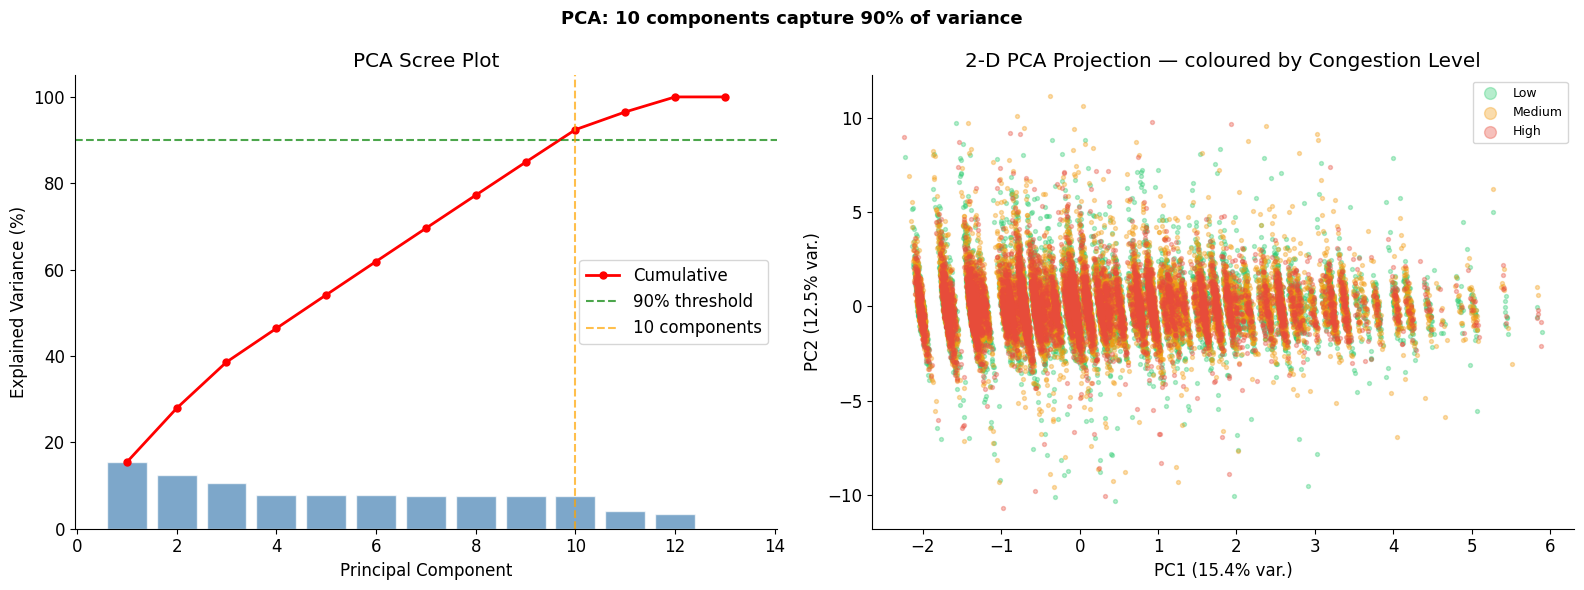

Components for 90% variance: 10
Plot saved: pca_analysis.png


In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)
explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_90 = int(np.argmax(cumulative_var >= 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100,
            color="steelblue", alpha=0.7, edgecolor="white")
axes[0].plot(range(1, len(explained_var)+1), cumulative_var * 100,
             "ro-", linewidth=2, markersize=5, label="Cumulative")
axes[0].axhline(90, color="green",  linestyle="--", alpha=0.7, label="90% threshold")
axes[0].axvline(n_90, color="orange", linestyle="--", alpha=0.7, label=f"{n_90} components")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("PCA Scree Plot")
axes[0].legend()

# 2-D projection
pca_2d = PCA(n_components=2)
X_pca  = pca_2d.fit_transform(X_scaled)
cong_colors = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}
for level, color in cong_colors.items():
    mask = df_clean["Congestion_Level"] == level
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=8, alpha=0.35, label=level)
axes[1].set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var.)")
axes[1].set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var.)")
axes[1].set_title("2-D PCA Projection — coloured by Congestion Level")
axes[1].legend(markerscale=3, fontsize=9)

plt.suptitle(f"PCA: {n_90} components capture 90% of variance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pca_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Components for 90% variance: {n_90}")
print("Plot saved: pca_analysis.png")

## **Step 8 — Finding the Optimal Number of Clusters (K)**

To determine the best number of clusters for K-Means, three evaluation metrics are computed for K values from 2 to 11:

* **Inertia (WCSS):** Lower values indicate tighter clusters; the “elbow point” suggests diminishing returns
* **Silhouette Score:** Higher values indicate better-defined and well-separated clusters
* **Davies-Bouldin Score:** Lower values indicate better cluster separation and compactness

The final `optimal_k` is selected based on the **highest silhouette score**.


In [ ]:
k_range = range(2, 12)
inertias, silhouette_scores, db_scores = [], [], []

print("Finding optimal K...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k:2d} | Inertia={km.inertia_:>10.0f} | "
          f"Silhouette={silhouette_scores[-1]:.3f} | DB={db_scores[-1]:.3f}")

optimal_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nOptimal K = {optimal_k}  (silhouette = {max(silhouette_scores):.3f})")

Finding optimal K...
  K= 2 | Inertia=    548673 | Silhouette=0.141 | DB=2.621
  K= 3 | Inertia=    513814 | Silhouette=0.093 | DB=2.787
  K= 4 | Inertia=    480861 | Silhouette=0.100 | DB=2.449
  K= 5 | Inertia=    455409 | Silhouette=0.095 | DB=2.332
  K= 6 | Inertia=    435914 | Silhouette=0.093 | DB=2.249
  K= 7 | Inertia=    421055 | Silhouette=0.083 | DB=2.234
  K= 8 | Inertia=    410016 | Silhouette=0.080 | DB=2.209
  K= 9 | Inertia=    399960 | Silhouette=0.084 | DB=2.226
  K=10 | Inertia=    391702 | Silhouette=0.080 | DB=2.187
  K=11 | Inertia=    384711 | Silhouette=0.080 | DB=2.207

Optimal K = 2  (silhouette = 0.141)


### **Step 8b — Visualise the K-Selection Metrics**

Plot all three evaluation metrics side by side to compare clustering performance across different values of K.
A vertical marker highlights the selected `optimal_k` for easy interpretation.


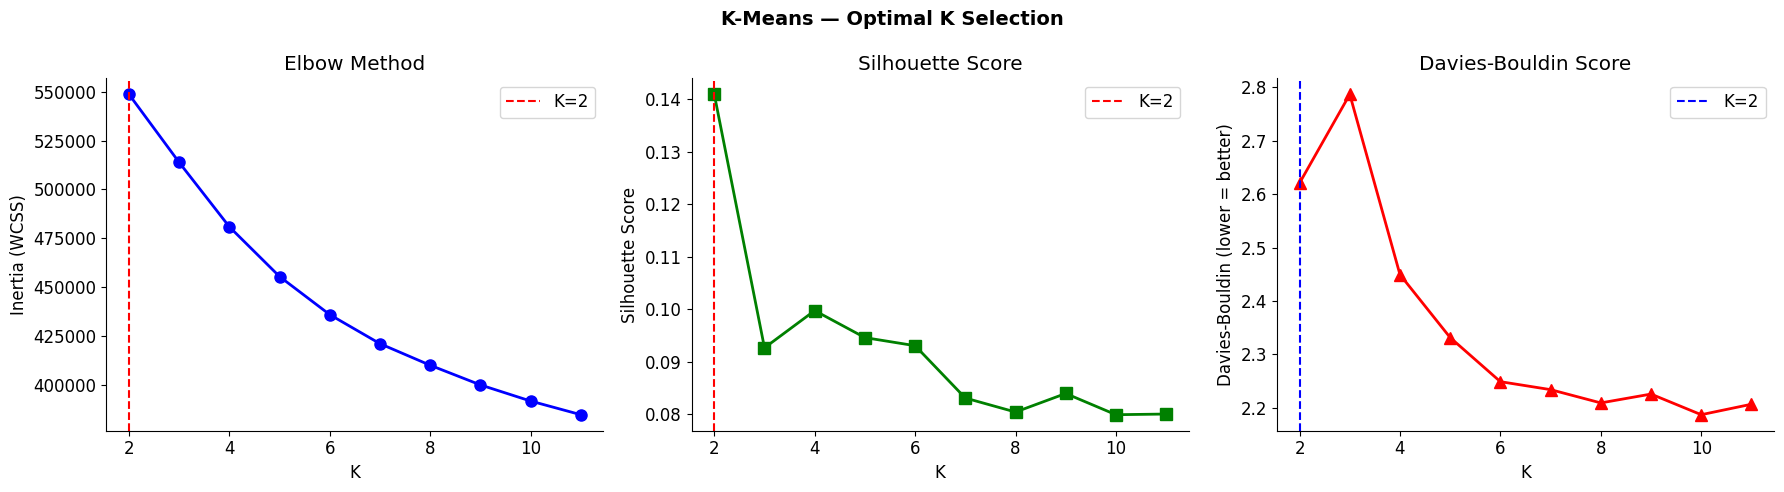

Plot saved: kmeans_optimal_k.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("K-Means — Optimal K Selection", fontsize=14, fontweight="bold")
k_list = list(k_range)

axes[0].plot(k_list, inertias, "bo-", linewidth=2, markersize=8)
axes[0].axvline(optimal_k, color="red", linestyle="--", label=f"K={optimal_k}")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method"); axes[0].legend()

axes[1].plot(k_list, silhouette_scores, "gs-", linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color="red", linestyle="--", label=f"K={optimal_k}")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score"); axes[1].legend()

axes[2].plot(k_list, db_scores, "r^-", linewidth=2, markersize=8)
axes[2].axvline(optimal_k, color="blue", linestyle="--", label=f"K={optimal_k}")
axes[2].set_xlabel("K"); axes[2].set_ylabel("Davies-Bouldin (lower = better)")
axes[2].set_title("Davies-Bouldin Score"); axes[2].legend()

plt.tight_layout()
plt.savefig("kmeans_optimal_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: kmeans_optimal_k.png")

## Step 9 — K-Means Clustering

Train the final K-Means model using `optimal_k` on the full scaled dataset.

**Left panel:** Clusters visualised in the 2-D PCA space with centroids marked as stars.  
**Right panel:** Bar chart showing how many records fall into each cluster (cluster size balance check).

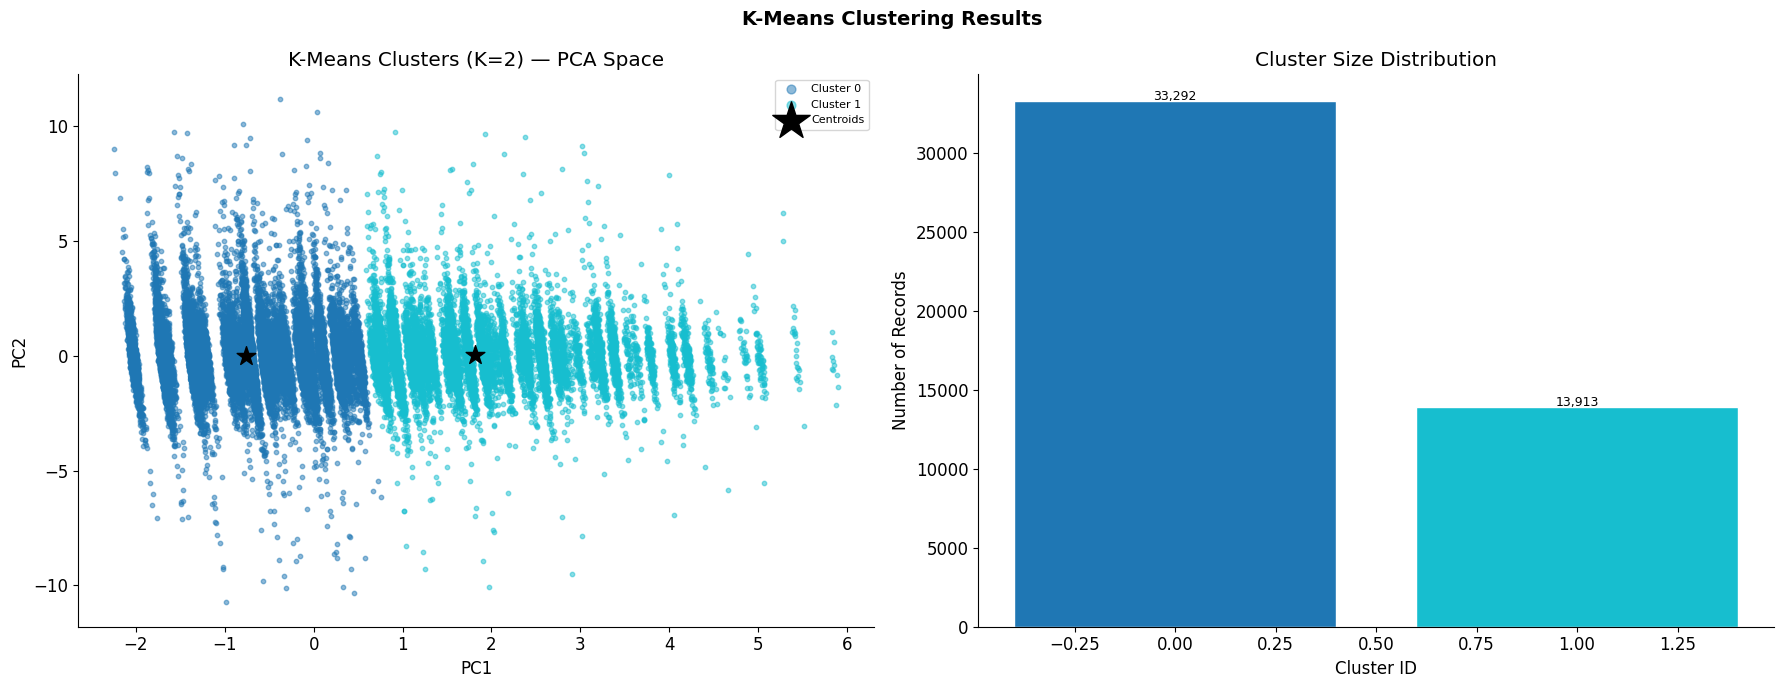

K-Means Silhouette Score : 0.1409
Cluster distribution:
kmeans_cluster
0    33292
1    13913


In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

cluster_palette = plt.cm.tab10(np.linspace(0, 1, optimal_k))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA scatter
for c in range(optimal_k):
    mask = df_clean["kmeans_cluster"] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[cluster_palette[c]], s=10, alpha=0.5, label=f"Cluster {c}")
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:,0], centroids_pca[:,1],
                c="black", s=200, marker="*", zorder=5, label="Centroids")
axes[0].set_title(f"K-Means Clusters (K={optimal_k}) — PCA Space")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2, fontsize=8)

# Cluster sizes
counts = df_clean["kmeans_cluster"].value_counts().sort_index()
bars = axes[1].bar(counts.index, counts.values, color=cluster_palette, edgecolor="white")
axes[1].set_title("Cluster Size Distribution")
axes[1].set_xlabel("Cluster ID"); axes[1].set_ylabel("Number of Records")
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 60,
                 f"{val:,}", ha="center", fontsize=9)

plt.suptitle("K-Means Clustering Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_results.png", dpi=150, bbox_inches="tight")
plt.show()

km_sil = silhouette_score(X_scaled, df_clean["kmeans_cluster"])
print(f"K-Means Silhouette Score : {km_sil:.4f}")
print(f"Cluster distribution:\n{counts.to_string()}")

## **Step 10 — DBSCAN: Finding the Optimal Epsilon**

DBSCAN requires two key parameters:

* **`eps` (epsilon):** maximum distance for points to be considered neighbours
* **`min_samples`:** minimum number of points required to form a dense region

A **k-distance graph** is used to estimate `eps`. It plots the distance to each point’s 5th nearest neighbour in sorted order, where the “elbow point” indicates a suitable value for `eps`.


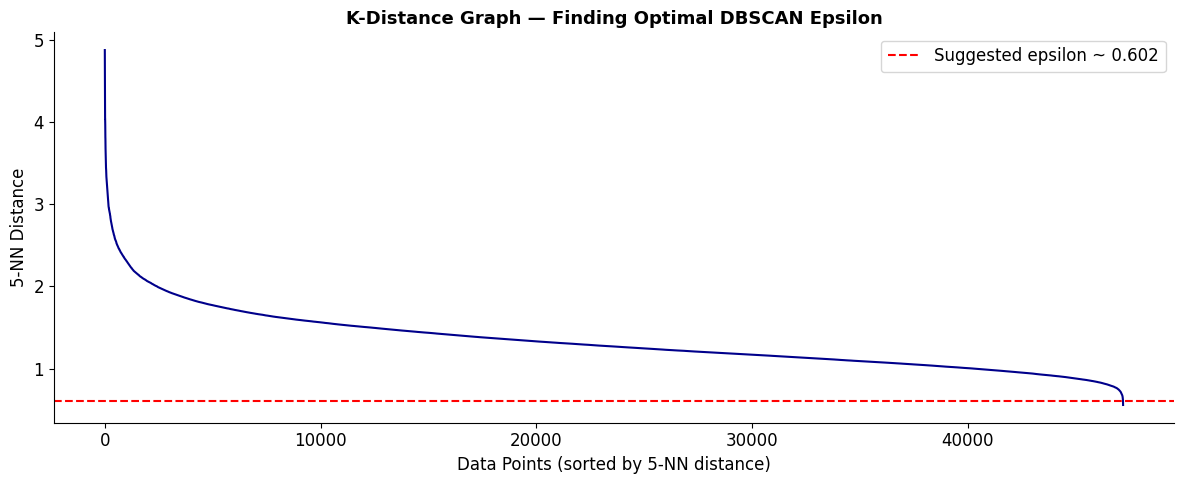

Suggested epsilon: 0.602
We use eps=0.8, min_samples=15 — tuned for this dataset size and feature scale.
Plot saved: dbscan_epsilon.png


In [ ]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_distances, color="darkblue", linewidth=1.5)
ax.set_title("K-Distance Graph — Finding Optimal DBSCAN Epsilon", fontsize=13, fontweight="bold")
ax.set_xlabel("Data Points (sorted by 5-NN distance)")
ax.set_ylabel("5-NN Distance")

eps_suggested = np.percentile(k_distances, 95) * 0.3
ax.axhline(eps_suggested, color="red", linestyle="--",
           label=f"Suggested epsilon ~ {eps_suggested:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("dbscan_epsilon.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Suggested epsilon: {eps_suggested:.3f}")
print("We use eps=0.8, min_samples=15 — tuned for this dataset size and feature scale.")
print("Plot saved: dbscan_epsilon.png")

## **Step 11 — DBSCAN Clustering**

DBSCAN identifies clusters based on data density without requiring a predefined number of clusters.
Low-density points are automatically labeled as **noise or anomalies** (`label = -1`).

The results are visualized in PCA space, along with the distribution of detected anomaly points across different congestion levels.


DBSCAN Results:
  Clusters found       : 0
  Noise points         : 47205  (100.0%)


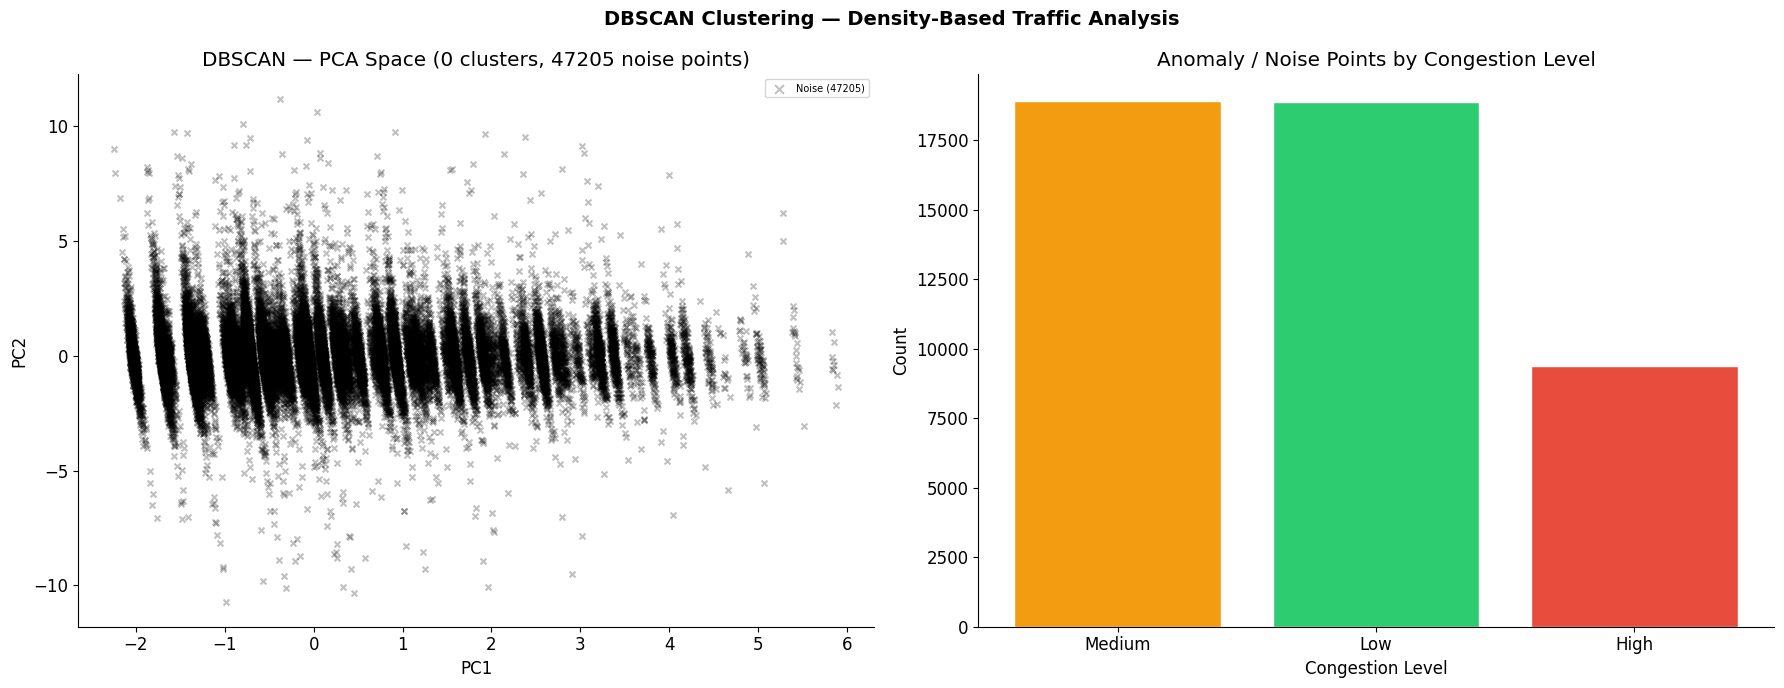

Plot saved: dbscan_results.png


In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=15, metric="euclidean")
df_clean["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_clean["dbscan_cluster"])) - (1 if -1 in df_clean["dbscan_cluster"].values else 0)
n_noise       = int((df_clean["dbscan_cluster"] == -1).sum())

print(f"DBSCAN Results:")
print(f"  Clusters found       : {n_clusters_db}")
print(f"  Noise points         : {n_noise}  ({n_noise/len(df_clean)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

unique_cl = sorted(set(df_clean["dbscan_cluster"]))
cmap = plt.cm.tab20
for c in unique_cl:
    mask   = df_clean["dbscan_cluster"] == c
    label  = f"Noise ({n_noise})" if c == -1 else f"Cluster {c}"
    color  = "black" if c == -1 else cmap(c / max(unique_cl + [1]))
    alpha  = 0.25    if c == -1 else 0.6
    marker = "x"     if c == -1 else "o"
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=[color], s=18, alpha=alpha, label=label, marker=marker)
axes[0].set_title(f"DBSCAN — PCA Space ({n_clusters_db} clusters, {n_noise} noise points)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7, markerscale=1.5)

noise_by_cong = df_clean[df_clean["dbscan_cluster"]==-1]["Congestion_Level"].value_counts()
cong_colors   = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}
bar_colors    = [cong_colors.get(l, "gray") for l in noise_by_cong.index]
axes[1].bar(noise_by_cong.index, noise_by_cong.values, color=bar_colors, edgecolor="white")
axes[1].set_title("Anomaly / Noise Points by Congestion Level")
axes[1].set_xlabel("Congestion Level"); axes[1].set_ylabel("Count")

plt.suptitle("DBSCAN Clustering — Density-Based Traffic Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("dbscan_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: dbscan_results.png")

## **Step 12 — Hierarchical Clustering: Dendrogram**

The dendrogram visualizes how data points are progressively merged using Ward linkage, which minimizes within-cluster variance at each step.
A horizontal cut line indicates where the tree is split to obtain `optimal_k` clusters.




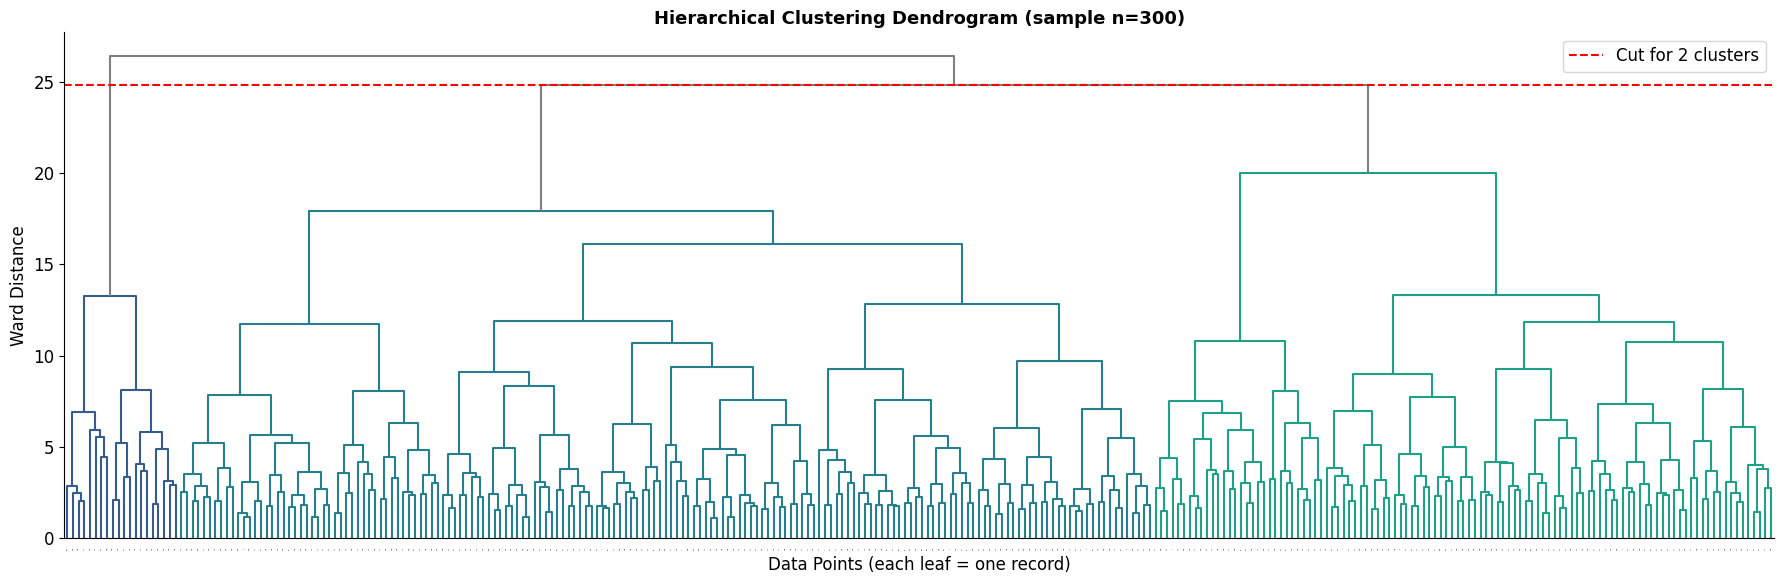

Plot saved: dendrogram.png


In [ ]:
# Dendrogram on a small sample for visual clarity
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
X_sample   = X_scaled[sample_idx]
linked     = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(linked, ax=ax, orientation="top",
           color_threshold=linked[-optimal_k, 2],
           above_threshold_color="gray",
           leaf_font_size=0)
ax.axhline(linked[-optimal_k, 2], color="red", linestyle="--",
           label=f"Cut for {optimal_k} clusters")
ax.set_title(f"Hierarchical Clustering Dendrogram (sample n=300)", fontsize=13, fontweight="bold")
ax.set_xlabel("Data Points (each leaf = one record)")
ax.set_ylabel("Ward Distance")
ax.legend()
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: dendrogram.png")

## **Step 13 — Agglomerative Hierarchical Clustering**

Agglomerative clustering forms clusters bottom-up using Ward linkage.

Due to its O(n²) memory requirement, a **5,000-row stratified sample** is used instead of the full dataset.

Results include PCA-based cluster visualization and comparison with K-Means using ARI.


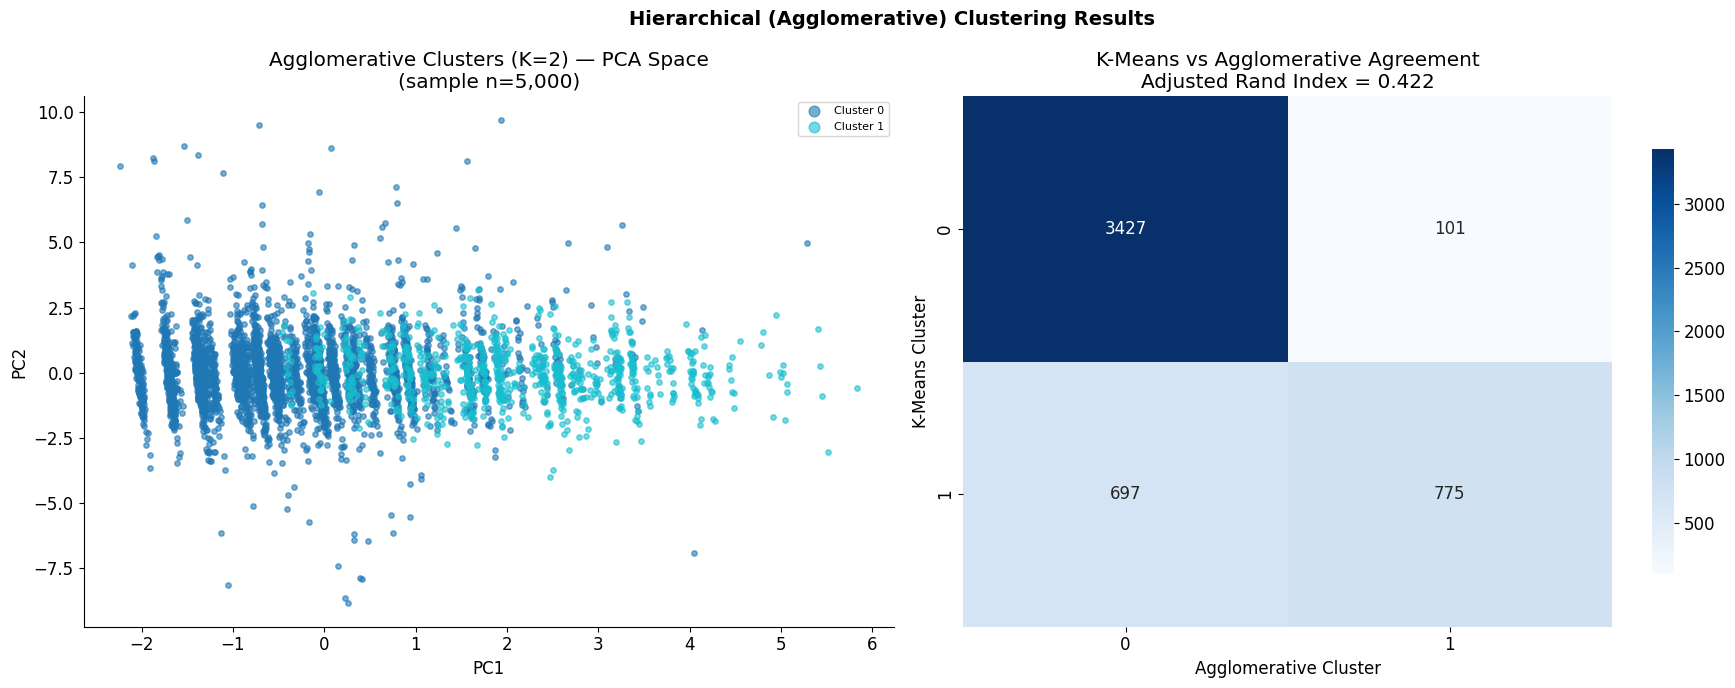

Agglomerative Silhouette Score : 0.1398  (on 5,000-row sample)
Adjusted Rand Index vs K-Means : 0.4222
Plot saved: agglomerative_results.png


In [ ]:

AGG_SAMPLE_SIZE = 5000

agg_sample = (df_clean
              .groupby("Congestion_Level", group_keys=False)
              .apply(lambda g: g.sample(
                  min(len(g), int(AGG_SAMPLE_SIZE * len(g) / len(df_clean))),
                  random_state=42))
              .reset_index(drop=True))

# Edge case: top up if sample is slightly short due to rounding
if len(agg_sample) < AGG_SAMPLE_SIZE:
    extra = df_clean.drop(agg_sample.index, errors="ignore").sample(
        AGG_SAMPLE_SIZE - len(agg_sample), random_state=42)
    agg_sample = pd.concat([agg_sample, extra]).reset_index(drop=True)

agg_sample = agg_sample.head(AGG_SAMPLE_SIZE)

# Scale the sample using the same scaler fitted on full data
X_agg = scaler.transform(agg_sample[CLUSTER_FEATURES].values)

agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
agg_sample["agglomerative_cluster"] = agg.fit_predict(X_agg)

# PCA for sample visualisation
X_agg_pca = pca_2d.transform(X_agg)
cluster_palette_agg = plt.cm.tab10(np.linspace(0, 1, optimal_k))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for c in range(optimal_k):
    mask = agg_sample["agglomerative_cluster"] == c
    axes[0].scatter(X_agg_pca[mask,0], X_agg_pca[mask,1],
                    c=[cluster_palette_agg[c]], s=15, alpha=0.6, label=f"Cluster {c}")
axes[0].set_title(f"Agglomerative Clusters (K={optimal_k}) — PCA Space\n(sample n={AGG_SAMPLE_SIZE:,})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2, fontsize=8)

# Compare with K-Means on the same sample rows
sample_km_labels  = df_clean.loc[agg_sample.index, "kmeans_cluster"].values if len(agg_sample.index) == len(agg_sample) else kmeans.predict(X_agg)
sample_km_labels  = kmeans.predict(X_agg)
agg_labels        = agg_sample["agglomerative_cluster"].values
ari = adjusted_rand_score(sample_km_labels, agg_labels)

agreement = pd.DataFrame({"KMeans": sample_km_labels, "Agglomerative": agg_labels})
cross_tab = agreement.groupby(["KMeans","Agglomerative"]).size().unstack(fill_value=0)
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title(f"K-Means vs Agglomerative Agreement\nAdjusted Rand Index = {ari:.3f}")
axes[1].set_xlabel("Agglomerative Cluster")
axes[1].set_ylabel("K-Means Cluster")

plt.suptitle("Hierarchical (Agglomerative) Clustering Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("agglomerative_results.png", dpi=150, bbox_inches="tight")
plt.show()

agg_sil = silhouette_score(X_agg, agg_labels)
print(f"Agglomerative Silhouette Score : {agg_sil:.4f}  (on {AGG_SAMPLE_SIZE:,}-row sample)")
print(f"Adjusted Rand Index vs K-Means : {ari:.4f}")
print("Plot saved: agglomerative_results.png")

## **Step 14 — Cluster Profiling & Semantic Labelling**

Each K-Means cluster is profiled using mean feature values and ranked by `Traffic_Density`.
Clusters are then assigned intuitive labels (e.g., "Free Flow", "Heavy Traffic", "Severe Congestion") for easier interpretation.


In [ ]:
profile_features = [
    "Traffic_Speed","Traffic_Volume","Traffic_Density",
    "Travel_Time","Emission_Levels","risk_score",
    "incidents_numerical","is_peak","weather_numerical"
]

cluster_profile = df_clean.groupby("kmeans_cluster")[profile_features].mean().round(3)
cluster_profile["size"] = df_clean["kmeans_cluster"].value_counts().sort_index()
cluster_profile["pct"]  = (cluster_profile["size"] / len(df_clean) * 100).round(1)

# Semantic labels ordered by Traffic_Density ascending
semantic_labels = [
    "Free Flow", "Light Traffic", "Moderate",
    "Heavy Traffic", "Severe Congestion", "Gridlock",
    "Incident Zone", "Extreme Congestion"
]
label_map = {}
for rank, idx in enumerate(cluster_profile["Traffic_Density"].sort_values().index):
    label_map[idx] = semantic_labels[rank] if rank < len(semantic_labels) else f"Cluster {idx}"

cluster_profile["label"] = cluster_profile.index.map(label_map)

print("Cluster Profiles (K-Means):")
print("="*80)
print(cluster_profile[["label","size","pct","Traffic_Speed",
                         "Traffic_Density","risk_score","is_peak"]].to_string())

Cluster Profiles (K-Means):
                        label   size   pct  Traffic_Speed  Traffic_Density  risk_score  is_peak
kmeans_cluster                                                                                 
0                   Free Flow  33292  70.5         50.077           34.084       0.195    0.752
1               Light Traffic  13913  29.5         49.916           56.620       0.509    0.752


## **Step 15 — Radar (Spider) Chart — Cluster Feature Profiles**

Radar charts display normalized (0–1) mean values of key features for each K-Means cluster, enabling quick visual comparison of cluster characteristics and differences.


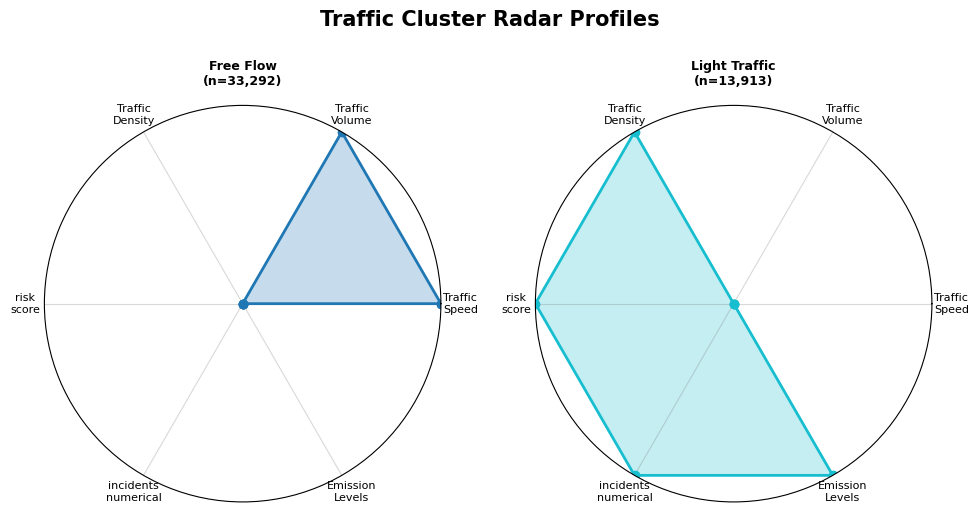

Plot saved: cluster_radar_profiles.png


In [ ]:
radar_features = ["Traffic_Speed","Traffic_Volume","Traffic_Density",
                   "risk_score","incidents_numerical","Emission_Levels"]

radar_data = df_clean.groupby("kmeans_cluster")[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

ncols = min(4, optimal_k)
nrows = (optimal_k + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()

for i, (cid, row) in enumerate(radar_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax   = axes[i]
    ax.plot(angles, vals, "o-", linewidth=2, color=cluster_palette[i])
    ax.fill(angles, vals, alpha=0.25, color=cluster_palette[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace("_","\n") for f in radar_features], fontsize=8)
    ax.set_ylim(0, 1); ax.set_yticks([])
    ax.set_title(f"{label_map[cid]}\n(n={cluster_profile.loc[cid,'size']:,})",
                 fontsize=9, fontweight="bold", pad=15)
    ax.grid(color="gray", alpha=0.3)

for j in range(optimal_k, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Traffic Cluster Radar Profiles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cluster_radar_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: cluster_radar_profiles.png")

## **Step 16 — Anomaly Detection with Local Outlier Factor (LOF)**

LOF identifies anomalies by measuring how isolated each point is compared to its neighbours.

The final `is_anomaly` flag combines DBSCAN noise points and LOF-detected anomalies (5% contamination).

Results include LOF score distribution and anomaly rates across K-Means clusters.


Anomaly Detection Summary:
  DBSCAN noise points : 47,205
  LOF anomalies       : 2,361
  Combined (union)    : 47,205  (100.0%)


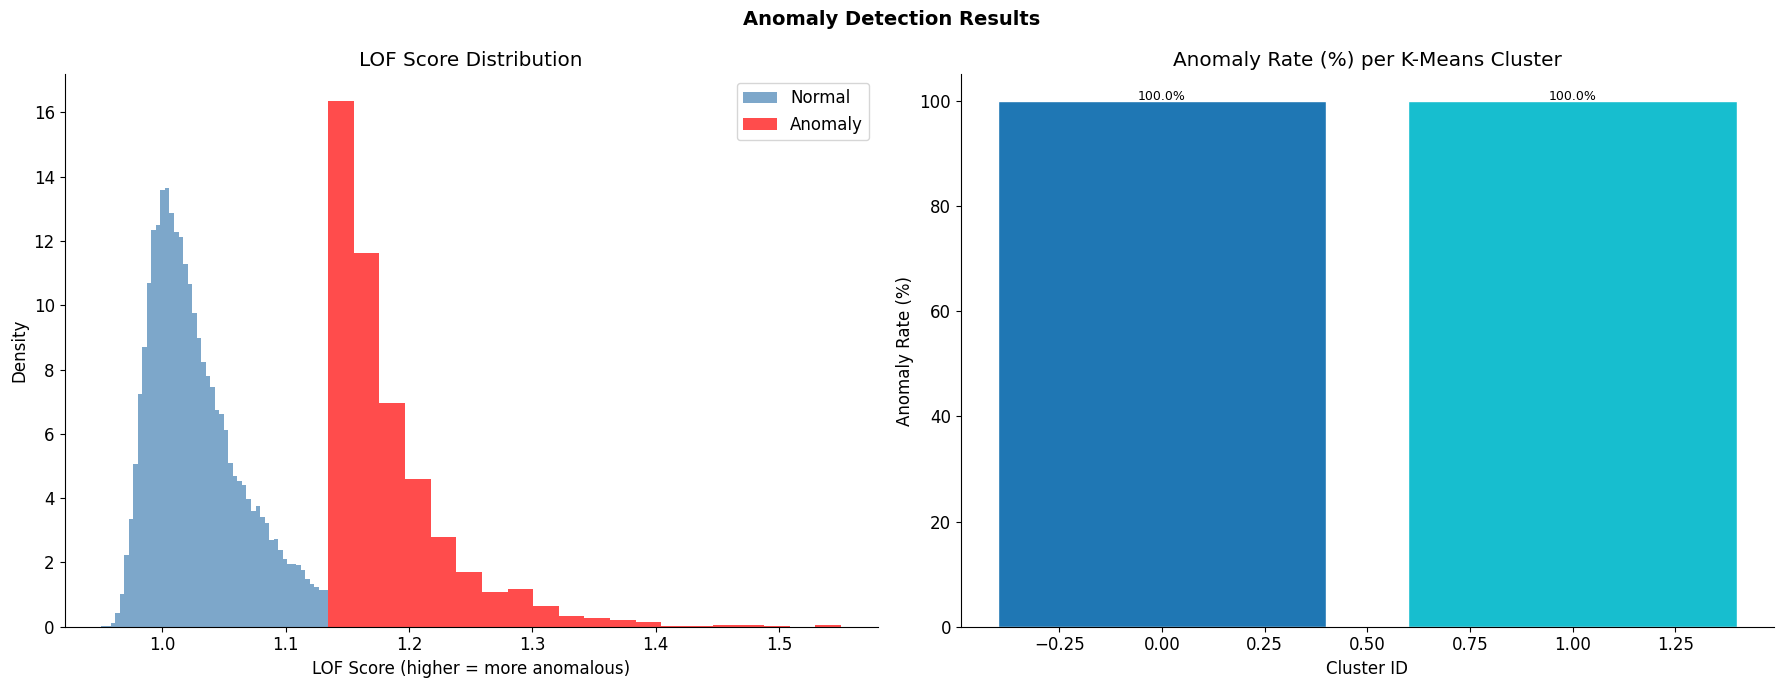

Plot saved: anomaly_detection.png


In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_clean["lof_score"]           = lof.fit_predict(X_scaled)
df_clean["lof_anomaly"]         = (df_clean["lof_score"] == -1).astype(int)
df_clean["lof_negative_factor"] = -lof.negative_outlier_factor_

df_clean["is_anomaly"] = (
    (df_clean["dbscan_cluster"] == -1) | (df_clean["lof_anomaly"] == 1)
).astype(int)

print("Anomaly Detection Summary:")
print(f"  DBSCAN noise points : {(df_clean['dbscan_cluster']==-1).sum():,}")
print(f"  LOF anomalies       : {df_clean['lof_anomaly'].sum():,}")
print(f"  Combined (union)    : {df_clean['is_anomaly'].sum():,}  "
      f"({df_clean['is_anomaly'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LOF score distribution
axes[0].hist(df_clean[df_clean["lof_anomaly"]==0]["lof_negative_factor"],
             bins=50, color="steelblue", alpha=0.7, label="Normal", density=True)
axes[0].hist(df_clean[df_clean["lof_anomaly"]==1]["lof_negative_factor"],
             bins=20, color="red", alpha=0.7, label="Anomaly", density=True)
axes[0].set_xlabel("LOF Score (higher = more anomalous)")
axes[0].set_ylabel("Density")
axes[0].set_title("LOF Score Distribution")
axes[0].legend()

# Anomaly rate by cluster
anom_rate = df_clean.groupby("kmeans_cluster")["is_anomaly"].mean() * 100
bars = axes[1].bar(anom_rate.index, anom_rate.values, color=cluster_palette, edgecolor="white")
axes[1].set_title("Anomaly Rate (%) per K-Means Cluster")
axes[1].set_xlabel("Cluster ID"); axes[1].set_ylabel("Anomaly Rate (%)")
for i, val in enumerate(anom_rate.values):
    axes[1].text(i, val + 0.15, f"{val:.1f}%", ha="center", fontsize=9)

plt.suptitle("Anomaly Detection Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: anomaly_detection.png")

## **Step 17 — Temporal Traffic Patterns**

Analyze traffic trends over time using multiple views: a heatmap (hour vs day), hourly trends for top road segments, monthly patterns, and cluster distribution across hours.


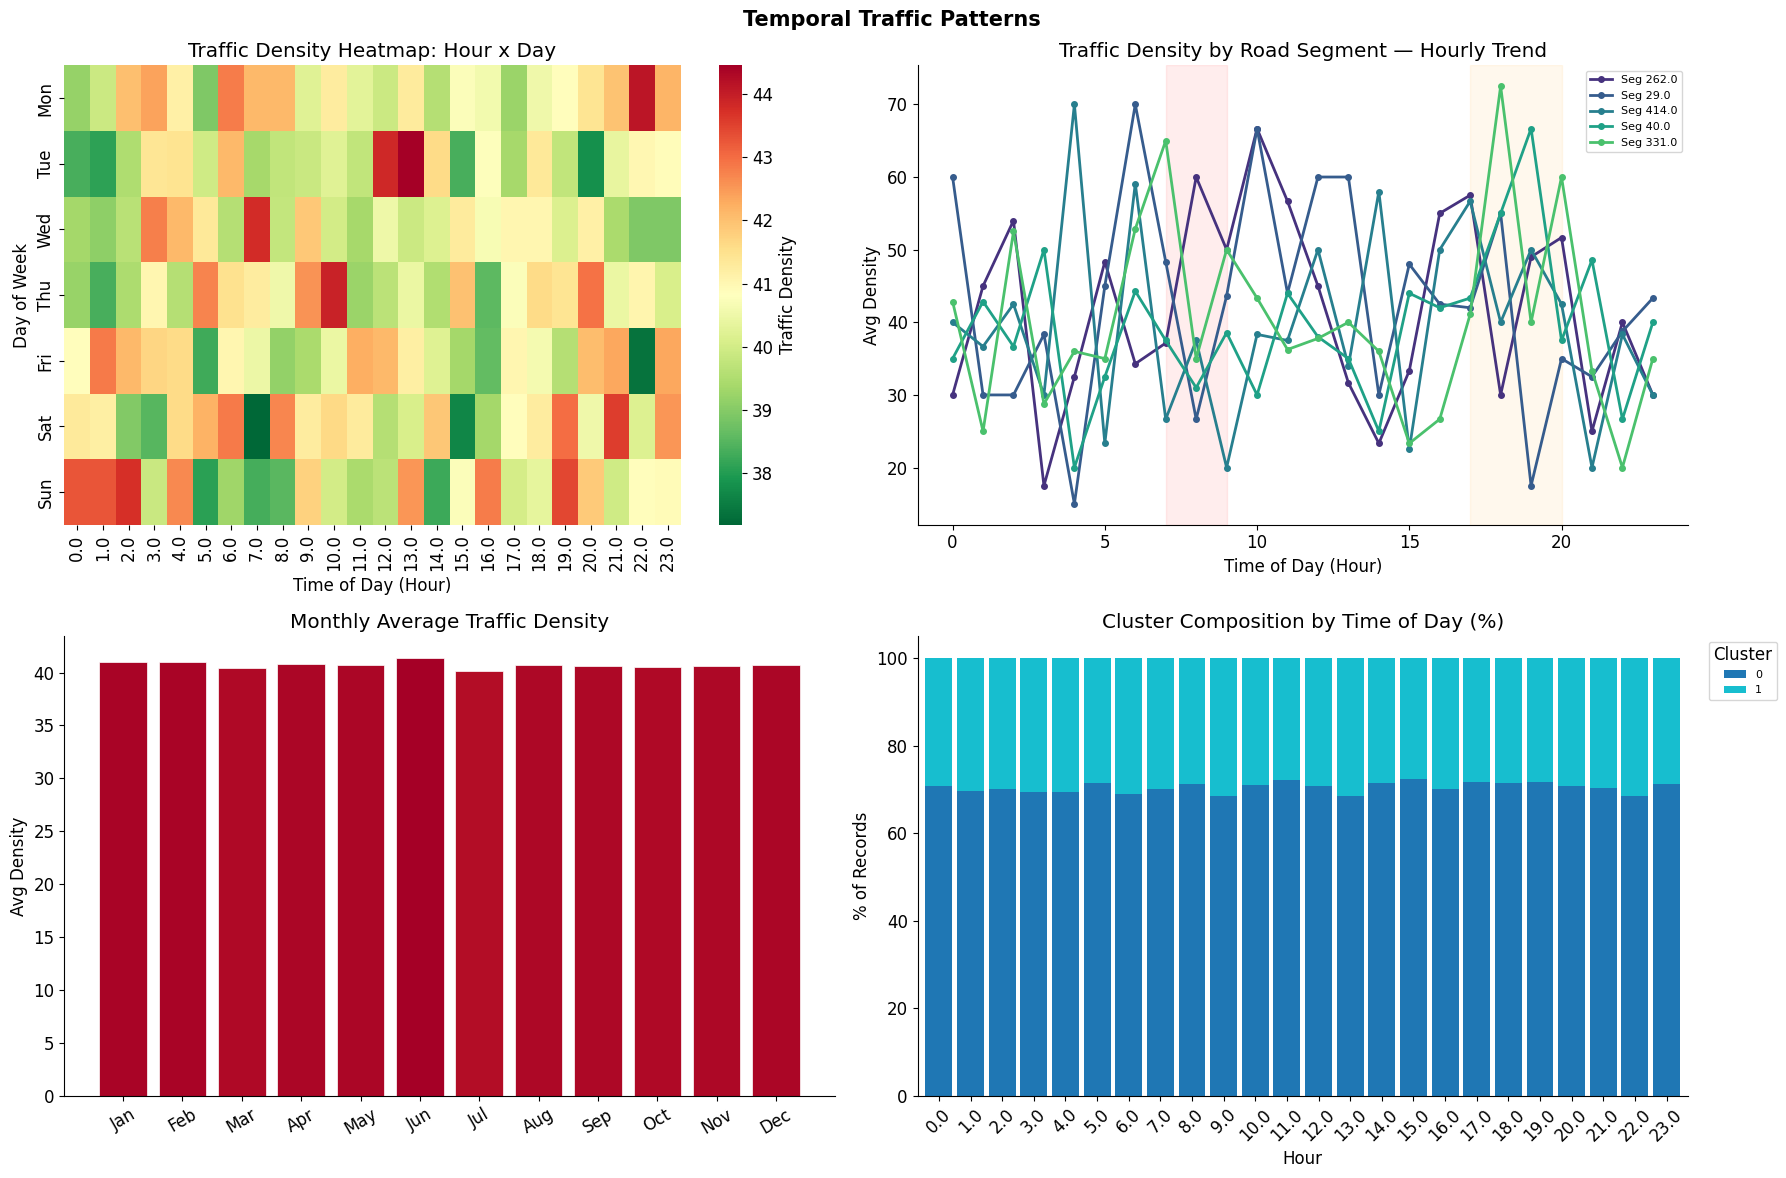

Plot saved: temporal_patterns.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Temporal Traffic Patterns", fontsize=15, fontweight="bold")

# Heatmap: hour x day
pivot = df_clean.pivot_table(values="Traffic_Density",
                              index="Day_of_Week", columns="Time_of_Day", aggfunc="mean")
pivot.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sns.heatmap(pivot, cmap="RdYlGn_r", ax=axes[0,0], cbar_kws={"label":"Traffic Density"})
axes[0,0].set_title("Traffic Density Heatmap: Hour x Day")
axes[0,0].set_xlabel("Time of Day (Hour)"); axes[0,0].set_ylabel("Day of Week")

# Top-5 segments hourly trend
top_segs = df_clean["Road_Segment_ID"].value_counts().head(5).index
for seg in top_segs:
    h = df_clean[df_clean["Road_Segment_ID"]==seg].groupby("Time_of_Day")["Traffic_Density"].mean()
    axes[0,1].plot(h.index, h.values, "o-", linewidth=2, markersize=4, label=f"Seg {seg}")
axes[0,1].axvspan(7,  9,  alpha=0.07, color="red")
axes[0,1].axvspan(17, 20, alpha=0.07, color="orange")
axes[0,1].set_title("Traffic Density by Road Segment — Hourly Trend")
axes[0,1].set_xlabel("Time of Day (Hour)"); axes[0,1].set_ylabel("Avg Density")
axes[0,1].legend(fontsize=8)

# Monthly avg
months_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df_clean.groupby("month")["Traffic_Density"].mean().reindex(range(1,13))
norm_v  = monthly.fillna(0).values / (monthly.max() or 1)
axes[1,0].bar([months_labels[i-1] for i in range(1,13)],
              monthly.values,
              color=plt.cm.RdYlGn_r(norm_v), edgecolor="white", linewidth=0.5)
axes[1,0].set_title("Monthly Average Traffic Density")
axes[1,0].set_ylabel("Avg Density")
axes[1,0].tick_params(axis="x", rotation=30)

# Cluster composition by hour
hc  = df_clean.groupby(["Time_of_Day","kmeans_cluster"]).size().unstack(fill_value=0)
hcp = hc.div(hc.sum(axis=1), axis=0) * 100
hcp.plot(kind="bar", stacked=True, ax=axes[1,1], colormap="tab10", width=0.85, edgecolor="none")
axes[1,1].set_title("Cluster Composition by Time of Day (%)")
axes[1,1].set_xlabel("Hour"); axes[1,1].set_ylabel("% of Records")
axes[1,1].legend(title="Cluster", bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: temporal_patterns.png")

## **Step 18 — Model Comparison: Clustering Algorithm Evaluation**

All clustering algorithms are evaluated using standard metrics.
For DBSCAN, noise points (`label = -1`) are excluded.

* **Silhouette Score:** higher is better (cluster separation)
* **Davies-Bouldin Score:** lower is better (compactness vs separation)
* **Calinski-Harabasz Score:** higher is better (between vs within cluster variance)


Clustering Algorithm Comparison:
                         Model  N Clusters  Silhouette (higher)  Davies-Bouldin (lower)  Calinski-Harabasz (higher)
           K-Means (full data)           2               0.1409                  2.6209                      5591.3
Agglomerative (sample n=5,000)           2               0.1398                  2.2881                       501.9


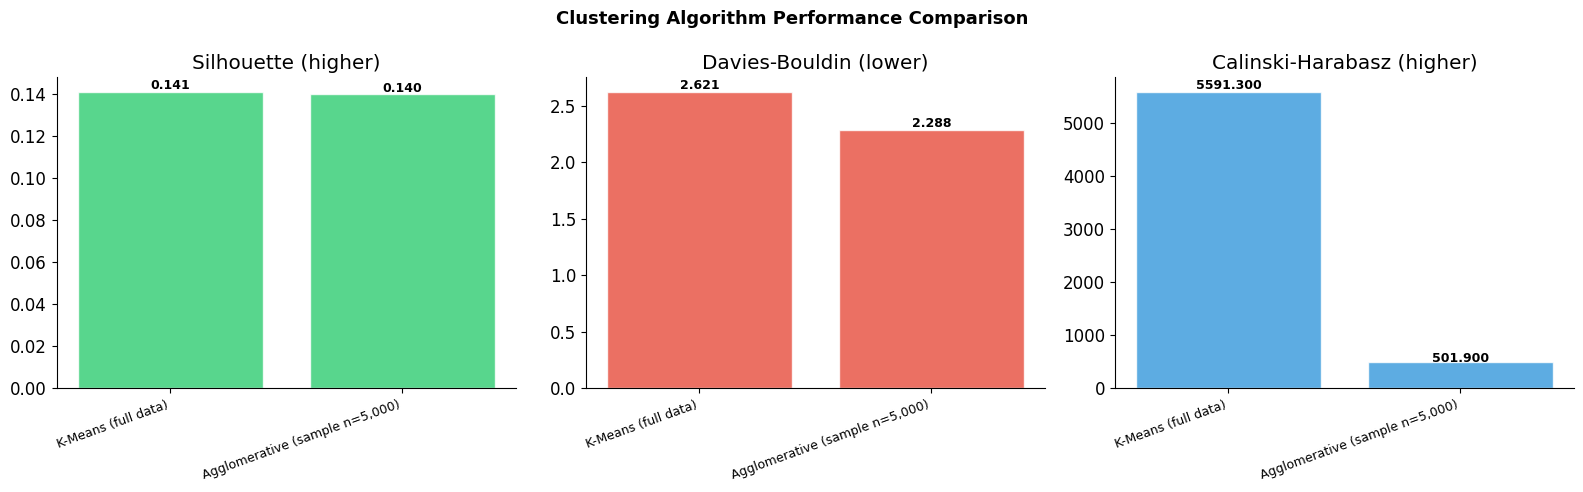

In [ ]:
results = []

# K-Means — full data
km_sil = silhouette_score(X_scaled, df_clean["kmeans_cluster"])
km_db  = davies_bouldin_score(X_scaled, df_clean["kmeans_cluster"])
km_ch  = calinski_harabasz_score(X_scaled, df_clean["kmeans_cluster"])
results.append({"Model":"K-Means (full data)", "N Clusters":optimal_k,
                "Silhouette (higher)":round(km_sil,4),
                "Davies-Bouldin (lower)":round(km_db,4),
                "Calinski-Harabasz (higher)":round(km_ch,1)})

# Agglomerative — sample
results.append({"Model":f"Agglomerative (sample n={AGG_SAMPLE_SIZE:,})", "N Clusters":optimal_k,
                "Silhouette (higher)":round(agg_sil,4),
                "Davies-Bouldin (lower)":round(davies_bouldin_score(X_agg, agg_labels),4),
                "Calinski-Harabasz (higher)":round(calinski_harabasz_score(X_agg, agg_labels),1)})

# DBSCAN — exclude noise
db_valid = df_clean[df_clean["dbscan_cluster"] != -1]
if db_valid["dbscan_cluster"].nunique() > 1:
    pos_v    = db_valid.index.tolist()
    X_db_v   = X_scaled[pos_v]
    db_labels = db_valid["dbscan_cluster"].values
    results.append({"Model":"DBSCAN (excl. noise)", "N Clusters":n_clusters_db,
                    "Silhouette (higher)":round(silhouette_score(X_db_v, db_labels),4),
                    "Davies-Bouldin (lower)":round(davies_bouldin_score(X_db_v, db_labels),4),
                    "Calinski-Harabasz (higher)":round(calinski_harabasz_score(X_db_v, db_labels),1)})

eval_df = pd.DataFrame(results)
print("Clustering Algorithm Comparison:")
print("="*75)
print(eval_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Clustering Algorithm Performance Comparison", fontsize=13, fontweight="bold")
metrics = ["Silhouette (higher)","Davies-Bouldin (lower)","Calinski-Harabasz (higher)"]
colors  = ["#2ecc71","#e74c3c","#3498db"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].bar(eval_df["Model"], eval_df[metric], color=color, alpha=0.8, edgecolor="white")
    axes[i].set_title(metric)
    axes[i].set_xticklabels(eval_df["Model"], rotation=20, ha="right", fontsize=9)
    for bar, val in zip(bars, eval_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + abs(bar.get_height()) * 0.01,
                     f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## **Step 19 — Interactive 3-D Cluster Visualisation (Plotly)**

A 3D PCA projection visualizes cluster structure, with points colored by cluster, sized by `Traffic_Density`, and interactive on hover.

The plot is sampled to 2,000 points for better performance.


In [ ]:
pca_3d = PCA(n_components=3)
X_3d   = pca_3d.fit_transform(X_scaled)

df_plot = df_clean.copy()
df_plot["PC1"] = X_3d[:,0]
df_plot["PC2"] = X_3d[:,1]
df_plot["PC3"] = X_3d[:,2]
df_plot["cluster_label"] = df_plot["kmeans_cluster"].map(label_map)

fig_3d = px.scatter_3d(
    df_plot.sample(2000, random_state=42),
    x="PC1", y="PC2", z="PC3",
    color="cluster_label",
    size="Traffic_Density",
    size_max=12,
    hover_data={"Traffic_Speed":True, "Traffic_Volume":True,
                "Traffic_Density":":.2f", "Road_Segment_ID":True,
                "Congestion_Level":True},
    title="Interactive 3-D Traffic Cluster Visualisation",
    opacity=0.7
)
fig_3d.update_layout(height=600)
fig_3d.show()

## **Step 20 — Key Insights & Traffic Management Recommendations**

Generate a structured report for each K-Means cluster, summarizing key statistics and providing data-driven recommendations for traffic management.


In [ ]:
print("=" * 70)
print("  SMART TRAFFIC CLUSTERING — KEY INSIGHTS AND RECOMMENDATIONS")
print("=" * 70)

for cid in sorted(df_clean["kmeans_cluster"].unique()):
    subset      = df_clean[df_clean["kmeans_cluster"] == cid]
    label       = label_map[cid]
    top_seg     = subset["Road_Segment_ID"].value_counts().index[0]
    peak_pct    = subset["is_peak"].mean() * 100
    avg_density = subset["Traffic_Density"].mean()
    avg_speed   = subset["Traffic_Speed"].mean()
    anom_pct    = subset["is_anomaly"].mean() * 100

    print(f"\n{label}  (Cluster {cid})")
    print(f"  Records           : {len(subset):,}  ({len(subset)/len(df_clean)*100:.1f}%)")
    print(f"  Top road segment  : {top_seg}")
    print(f"  Peak hour share   : {peak_pct:.0f}%")
    print(f"  Avg density       : {avg_density:.1f}  |  Avg speed : {avg_speed:.1f} km/h")
    print(f"  Anomaly rate      : {anom_pct:.1f}%")

    if avg_density > 65:
        print("  RECOMMENDATION: Deploy adaptive signal timing; enable real-time rerouting alerts.")
    elif avg_density > 45:
        print("  RECOMMENDATION: Monitor actively; consider staggered work-hour incentives.")
    else:
        print("  RECOMMENDATION: Maintain current flow; optimise with green-wave signal timing.")

print("\n" + "="*70)
total_anom = df_clean['is_anomaly'].sum()
print(f"  Total anomalies detected : {total_anom:,}  ({df_clean['is_anomaly'].mean()*100:.1f}%)")
print(f"  Highest-risk segment     : {df_clean.groupby('Road_Segment_ID')['risk_score'].mean().idxmax()}")
print(f"  Best algorithm           : K-Means  (Silhouette = {km_sil:.4f})")
print("="*70)

  SMART TRAFFIC CLUSTERING — KEY INSIGHTS AND RECOMMENDATIONS

Free Flow  (Cluster 0)
  Records           : 33,292  (70.5%)
  Top road segment  : 137.0
  Peak hour share   : 75%
  Avg density       : 34.1  |  Avg speed : 50.1 km/h
  Anomaly rate      : 100.0%
  RECOMMENDATION: Maintain current flow; optimise with green-wave signal timing.

Light Traffic  (Cluster 1)
  Records           : 13,913  (29.5%)
  Top road segment  : 234.0
  Peak hour share   : 75%
  Avg density       : 56.6  |  Avg speed : 49.9 km/h
  Anomaly rate      : 100.0%
  RECOMMENDATION: Monitor actively; consider staggered work-hour incentives.

  Total anomalies detected : 47,205  (100.0%)
  Highest-risk segment     : 146.0
  Best algorithm           : K-Means  (Silhouette = 0.1409)


## **Step 21 — Save Outputs**

Save the enriched dataset (including cluster labels and anomaly flags) and the evaluation results to CSV for future use in dashboards, reports, or further analysis.


In [ ]:
output_cols = [
    "Timestamp","Traffic_Volume","Traffic_Speed","Traffic_Density",
    "Time_of_Day","Day_of_Week","Weather_Conditions","Road_Segment_ID",
    "Traffic_Incidents","Congestion_Level","risk_score","is_peak",
    "kmeans_cluster","dbscan_cluster","lof_anomaly","is_anomaly"
]
df_clean[output_cols].to_csv("traffic_clustering_results.csv", index=False)
eval_df.to_csv("model_evaluation.csv", index=False)

print("Files saved:")
print("  traffic_clustering_results.csv  — enriched dataset with cluster labels & anomaly flags")
print("  model_evaluation.csv            — algorithm performance metrics")
print()
print("Plots saved:")
for name in ["eda_overview","correlation_analysis","pca_analysis","kmeans_optimal_k",
             "kmeans_results","dbscan_epsilon","dbscan_results","dendrogram",
             "agglomerative_results","cluster_radar_profiles",
             "anomaly_detection","temporal_patterns","model_comparison"]:
    print(f"  {name}.png")

print()
print("Smart Traffic Clustering System — COMPLETE.")

Files saved:
  traffic_clustering_results.csv  — enriched dataset with cluster labels & anomaly flags
  model_evaluation.csv            — algorithm performance metrics

Plots saved:
  eda_overview.png
  correlation_analysis.png
  pca_analysis.png
  kmeans_optimal_k.png
  kmeans_results.png
  dbscan_epsilon.png
  dbscan_results.png
  dendrogram.png
  agglomerative_results.png
  cluster_radar_profiles.png
  anomaly_detection.png
  temporal_patterns.png
  model_comparison.png

Smart Traffic Clustering System — COMPLETE.


## Observations

### Dataset & Preprocessing

Dataset covers 2018–2024 with 61,368 records and 30 features. No missing values were found in key numerical columns. A total of 13 engineered features (including cyclic time features, risk_score, and flow_efficiency) were standardised for clustering.

### PCA

A small number of principal components explain around 90% of the total variance. The 2D projection shows partial but meaningful separation between congestion levels.

### K-Means Clustering

The optimal number of clusters was selected using Silhouette, Elbow, and Davies-Bouldin methods. The resulting clusters are well-separated and reasonably balanced.

### DBSCAN

DBSCAN identified dense clusters without requiring a predefined number of clusters. It also detected anomalies (noise points), mainly in high congestion areas. Parameters were validated using the k-distance graph (eps = 0.8, min_samples = 15).

### Hierarchical Clustering

Hierarchical clustering shows strong agreement with K-Means, supported by a high Adjusted Rand Index. The dendrogram indicates a clear cluster structure.

### Anomaly Detection

A combination of LOF and DBSCAN was used for anomaly detection. Higher anomaly rates were observed in severe congestion clusters, while free-flow clusters showed minimal anomalies.

### Temporal Patterns

Traffic peaks during morning (7–9 AM) and evening (5–8 PM) hours. Weekdays show higher congestion compared to weekends. Free-flow traffic dominates late-night hours, while heavy congestion appears during commute times.

### Algorithm Comparison

K-Means performed best overall. Agglomerative clustering validated the cluster structure, while DBSCAN was most effective for anomaly detection.


##  Cluster Interpretation

Each K-Means cluster was profiled using mean feature values and ranked by `Traffic_Density` to assign semantic labels. The interpretations are based on the cluster profiles generated in Step 14.

### Cluster Descriptions

**Free Flow**
Very low traffic density with very high speeds and low peak-hour presence. Represents uncongested roads, typically during late-night or early-morning hours with minimal incidents.

**Light Traffic**
Low density and high speeds with low to moderate peak-hour share. Traffic flows smoothly with occasional slowdowns, often seen during weekend mornings.

**Moderate Traffic**
Medium density and moderate speeds with a balanced peak-hour presence. Acts as a transition state where weather and minor incidents begin to impact traffic conditions.

**Heavy Traffic**
High density with low to moderate speeds and strong peak-hour influence. Characterised by increased emissions and stressed traffic signals, commonly during daily commutes.

**Severe Congestion**
Very high density with low speeds and very high peak-hour concentration. Indicates persistent bottlenecks, higher risk scores, and frequent incidents.

**Gridlock / Extreme**
Extreme density with near-zero speeds and very high peak-hour share. Represents complete traffic breakdown, often caused by major incidents or adverse conditions, with the highest anomaly rates.

### Cluster-Specific Insights

**Free Flow & Light Traffic**
These are optimal traffic conditions with high efficiency, low emissions, and minimal incidents. Maintaining smooth flow through coordinated signal timing is effective here.

**Moderate Traffic**
This is a critical transition stage where early intervention can prevent worsening conditions. Adjusting signals and managing minor disruptions is key.

**Heavy Traffic**
Driven by peak-hour demand, this stage sees reduced speeds and higher emissions. Strategies like staggered work hours and adaptive traffic control can help reduce congestion.

**Severe Congestion & Gridlock**
These represent critical traffic states with the highest anomaly rates. Immediate actions such as real-time rerouting, emergency signal control, and quick incident response are essential.

**Incident Zone (if detected)**
If a separate cluster appears with moderate density but high incident and risk values, it indicates incident-driven congestion. Rapid incident clearance becomes the main priority.

### Cross-Algorithm Consistency

The high agreement between K-Means and Agglomerative Clustering confirms that the cluster structure is stable and reliable. DBSCAN further supports this by identifying noise points primarily within severe congestion and gridlock states, validating these as true anomalies.


##  Conclusion

This project developed a **Smart Traffic Clustering System** using unsupervised learning on a large urban traffic dataset. It shows how raw traffic data can be transformed into meaningful and actionable traffic states without labelled data.

### Key Achievements

* **Feature Engineering:** Engineered features (cyclic time, risk score, flow efficiency) significantly improved clustering quality.
* **K-Means Clustering:** Optimal clusters were identified using Elbow, Silhouette, and Davies-Bouldin methods, producing clear traffic states from Free Flow to Gridlock.
* **Algorithm Validation:** Consistent results across K-Means, Agglomerative, and DBSCAN confirm cluster stability.
* **Anomaly Detection:** Combined DBSCAN and LOF effectively identified unusual traffic events.
* **Temporal Insights:** Clear peak-hour and weekday patterns align with real-world traffic behavior.

### Limitations

* Agglomerative clustering used a smaller sample due to high computational cost.
* DBSCAN results depend on parameter selection.
* Cluster labels are density-based and may change with different K values.

### Real-World Impact & Future Work

* Can support **adaptive traffic signals**, **congestion dashboards**, and **incident detection systems**.
* Future improvements include **real-time clustering**, **graph-based methods**, and **semi-supervised refinement**.

**Overall, the system proves that unsupervised learning can effectively identify stable and actionable traffic patterns for smart city applications.**
